# Clustering
### Jimmy Azar

We'll focus on the problem of clustering, i.e. finding which objects belong to the same group or cluster. Clustering is the task of finding structure in the data.

## Hierarchical Clustering

In hierarchical clustering we need to choose two parameters: a dissimilarity measure and a type of linkage. We'll be using Euclidean distance as a measure for dissimilarity, whereas common linkage types are *complete*, *single*, or *average*.

We load the data from the file 'clust14.txt' which consists of 140 objects with two features, and we create a 2D scatter plot. We aslo generate a dendrogram using complete linkage. To perform clustering, we still need to decide upon the number of clusters which in this case we'll set to *k = 14*. Then, we cluster the data accordingly and obtain object labels. Finally, we use the object labels in order to create a 2D scatter plot by assigning different colors to the clusters.

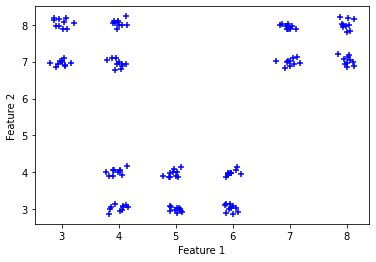

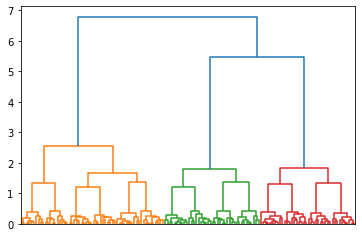

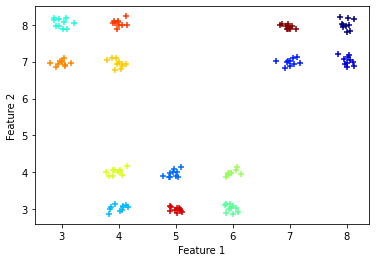

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path_to_file = '../data/clust14.txt'
X = pd.read_csv(path_to_file, sep=' ')
 
plt.scatter(X['f1'],X['f2'],color='blue',marker='+')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

from scipy.cluster.hierarchy import linkage, dendrogram
Z = linkage(X, method='complete')
dendrogram(Z, no_labels=True)
plt.show()

from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=14, linkage='complete')
model.fit(X)
model.labels_

plt.scatter(X['f1'],X['f2'],c=model.labels_,cmap=plt.cm.jet,marker='+')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

Building upon the previous task, we construct a fusion curve. The largest drop in the curve determines the number of clusters to choose.

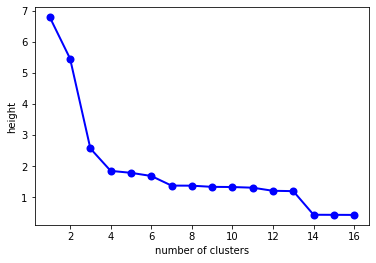

In [2]:
Fc = Z[::-1,2]

plt.plot(np.arange(1,16+1),Fc[:16],c='blue',linewidth=2)
plt.scatter(np.arange(1,16+1),Fc[:16],c='blue',linewidth=2)
plt.xlabel('number of clusters')
plt.ylabel('height')
plt.show()

We load the data from the the file 'parallelclust.txt' and create a 2D scatter plot. Then, we construct a dendrogram using complete linkage. We set the number of clusters to two and show a 2D scatter plot with different colors assigned to the different clusters. Then, we repeat the clustering, however this time we change the linkage type to *single*.

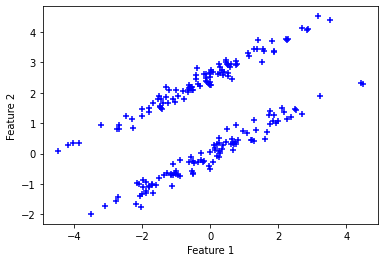

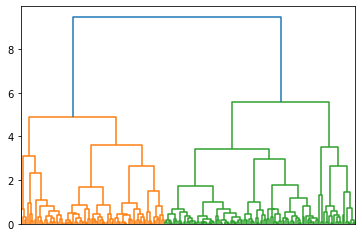

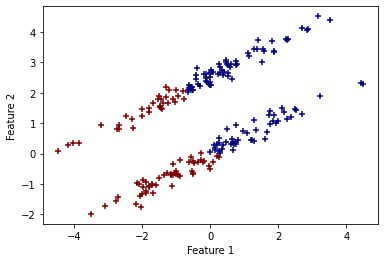

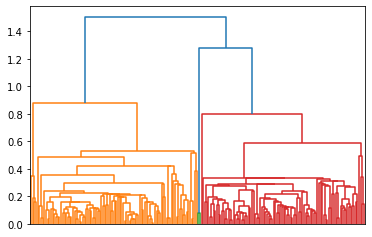

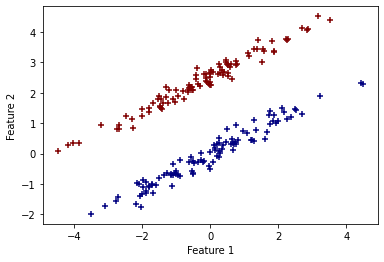

In [3]:
path_to_file = '../data/parallelclust.txt'
X = pd.read_csv(path_to_file, sep=' ')

plt.scatter(X['f1'],X['f2'],c='blue',marker='+')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# complete linkage
Z = linkage(X, method='complete')
dendrogram(Z, no_labels=True)
plt.show()

model = AgglomerativeClustering(n_clusters=2, linkage='complete')
model.fit(X)
model.labels_ 

plt.scatter(X['f1'],X['f2'],c=model.labels_,cmap=plt.cm.jet,marker='+')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# single linkage
Z = linkage(X, method='single')
dendrogram(Z, no_labels=True)
plt.show()

model = AgglomerativeClustering(n_clusters=2, linkage='single')
model.fit(X)
model.labels_ 

plt.scatter(X['f1'],X['f2'],c=model.labels_,cmap=plt.cm.jet,marker='+')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

We load the data from the file 'clust3.txt' which contains a dataset consisting of 150 objects in 2 dimensions. Then, we generate a scatter plot and deduce the number of available clusters.

We also compute the Davies-Bouldin index within a for loop to obtain an array of scores, one score for each value of `k = 2, 3, ..., M`, where `k` represents the number of clusters. We plot the Davies-Bouldin index as a function of the number of clusters `k` for the given dataset using complete linkage. We set the maximum number of clusters to try out to `M = 10`. The optimal number of clusters to choose is that which minimizes the Davies-Bouldin index.

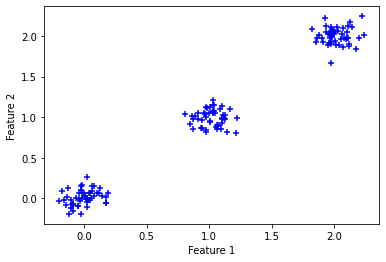

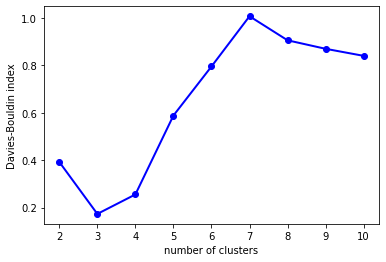

In [4]:
path_to_file = '../data/clust3.txt'
X = pd.read_csv(path_to_file, sep=' ')

plt.scatter(X['f1'],X['f2'],c='blue',marker='+')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

from sklearn.metrics import davies_bouldin_score 

indices = []
for i in range(2,10+1):
    model = AgglomerativeClustering(n_clusters=i, linkage='complete').fit(X)
    indices.append(davies_bouldin_score(X, model.labels_)) 

plt.plot(range(2,10+1),indices,'b-o',linewidth=2) 
plt.xlabel('number of clusters')
plt.ylabel('Davies-Bouldin index')
plt.show()

## K-means Clustering

We load the data from the file 'gaussianclust.txt' and create a 2D scatter plot. Then, we run the k-means algorithm with k = 2. We set the maximum number of iterations, `max_iter`, to 100 and the number of initializations, `n_init`, to 10. We can access the cluster labels using the `labels_` attribute after fitting the model. The cluster centers can also be accessed using the `cluster_centers_` attribute. We create a scatter plot of the two clusters given in different color along with their centroids.

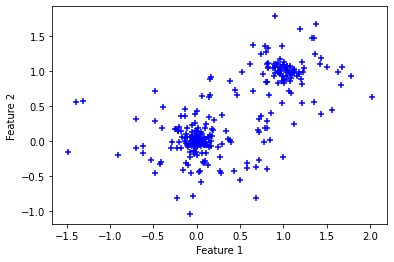

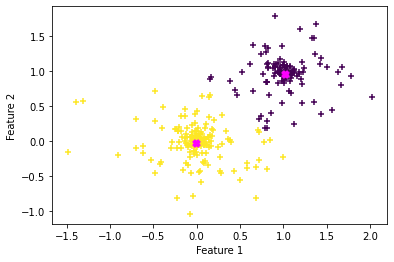

In [5]:
path_to_file = '../data/gaussianclust.txt'
X = pd.read_csv(path_to_file, sep=' ')

plt.scatter(X['f1'],X['f2'],c='blue',marker='+')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, max_iter=100, n_init=10).fit(X)
model.labels_
model.cluster_centers_ # each row is a centroid
model.predict([[0, 0], [12, 3]])
       
plt.scatter(X['f1'], X['f2'], c=model.labels_, marker='+')
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], c='magenta', linewidth=4, marker='x')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Gaussian Mixture Model

Clustering based on a Gaussian mixture model uses the expectation-maximization (EM) algorithm to estimate the parameters of the Gaussian models.

Load the data from the file 'clust3.txt'. We can set the number of clusters to 3 and fit a GMM model to the data to obtain cluster labels. Then, we can create a scatter plot of the data using different colors for the different clusters.

However, let's run the mixture of Gaussians clustering within a *for* loop for each of `n_components` = 1,2,...,9 and obtain the Bayesian information criterion in each case using the fitted model. We then plot the BIC values as a function of the number of clusters. The optimal number of clusters to choose is that which minimizes the BIC.

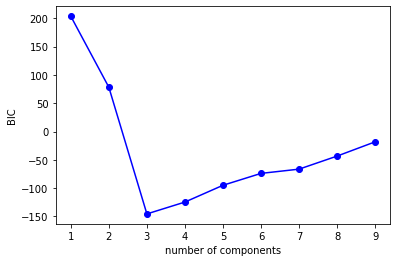

In [6]:
path_to_file = '../data/clust3.txt'
X = pd.read_csv(path_to_file, sep=' ')

from sklearn import mixture

model_bic = []
for i in range(1,9+1):
    model = mixture.GaussianMixture(n_components=i, covariance_type='full').fit(X)
    model_bic.append(model.bic(X))

plt.plot(range(1,9+1), model_bic, 'b-o')
plt.xlabel('number of components')
plt.ylabel('BIC')
plt.show()

## Self-Organizing Maps

SOMs are iterative methods that construct a topographic mapping from a high dimensional feature space (data space) to a lower dimensional map space which is two dimensional in most cases. This latter space consists of a grid of cluster centers each of which has a corresponding position in the original data space. Cluster centers that are neighbors in data space are also neighbors in map space. As the self-organizing map is trained, the centers in data space move around so as to cover the data in an optimal manner. We can then view map space in order to gain insight on the structure of the data in the original data space.

We load the iris dataset and create a scatter plot using the last two features. Then, we build a self-organizing map with size (10,10). The resulting image shows the U-matrix (distance map to neighbors) which helps us decide on the number of clusters in the data.

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip available: 22.3.1 -> 24.0
[notice] To update, run: pip3 install --upgrade pip


/home/sysadmin/.local/lib/python3.7/site-packages/minisom.py:389: ComplexWarning: Casting complex values to real discards the imaginary part
  c2*pc[pc_order[1]]


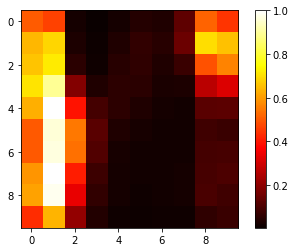

In [7]:
# minisom is from: https://github.com/JustGlowing/minisom
import sys
!{sys.executable} -m pip install minisom

from minisom import MiniSom 
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data[:,-2:]

n_neurons = 10 
m_neurons = 10

som = MiniSom(n_neurons, m_neurons, X.shape[1], sigma=1.5, learning_rate=0.05, neighborhood_function='gaussian')
som.pca_weights_init(X)
som.train(X, 5000, verbose=False)  

plt.imshow(som.distance_map().T, cmap='hot')
plt.colorbar()
plt.show()

## Fuzzy c-means

Fuzzy c-means is a form of weighted k-means wherein a membership value is assigned to each cluster. We'll apply fuzzy c-means to segment an image of a tissue section taken from a patient.

We load and display the image 'tissue.png'. A color image is made up of three matrices (one for the red channel, one for blue, and one for green). We find that the dimensions of the image are 1544 x 2080 x 3. Next, we place the image's red, green, and blue channels (2D arrays) as single columns in a matrix, X,.

To perform pixel classification using fuzzy c-means, we specify `n_clusters`, the number of clusters desired, `max_iter`, the maximum number of iterations to perform, and the exponent `m`, which controls the fuzziness level. 

The input data, X, should be in standard form, that is features as columns and objects as rows. In this case, we have three features corresponding to the three color channels R, G, and B. The number of objects is the number of pixels in the image (each pixel needs to be classified). We set the number of clusters to 4 since we expect the different clusters to cover the white background, purple nuclei, brown DAB stain of basal cells, and pink cytoplasm. 

The membership value of every pixel to each of the four clusters can be accessed through the attribute, `u`, of the trained model. We derive the four membership images by reshaping these values according to the size of the image.

Finally, we show each of these four images (pmap0, ..., pmap3) along with their pseudo-colored versions side-by-side.

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip available: 22.3.1 -> 24.0
[notice] To update, run: pip3 install --upgrade pip


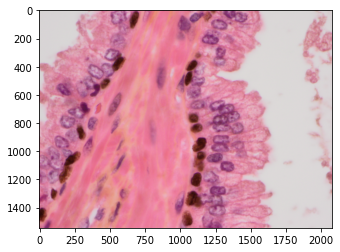

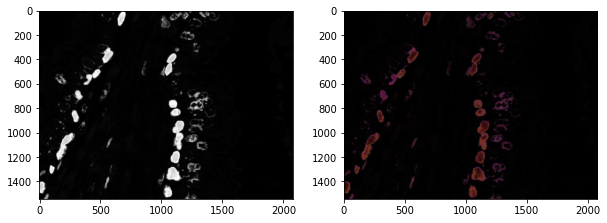

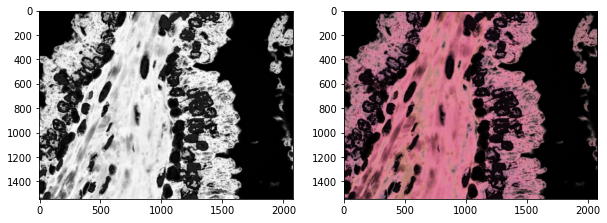

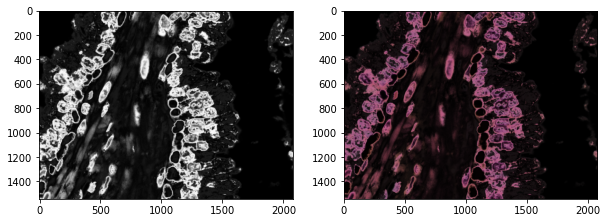

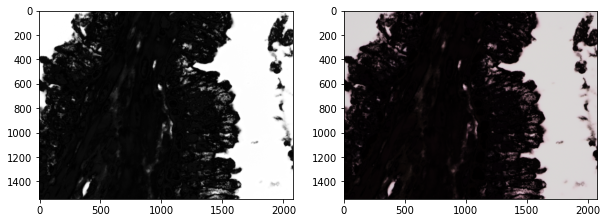

In [8]:
import sys
import warnings

warnings.filterwarnings('ignore')
!{sys.executable} -m pip install fuzzy-c-means
from fcmeans import FCM

path_to_file = '../data/tissue.png'
image = plt.imread(path_to_file)
plt.imshow(image)
plt.show()

R = image[:,:,0].ravel()
G = image[:,:,1].ravel()
B = image[:,:,2].ravel()

X = np.stack([R,G,B],axis=1)

fcm = FCM(n_clusters=4, max_iter=100, m=2)
fcm.fit(X)

# output
fcm_centers = fcm.centers
fcm_memberships = fcm.u
fcm_labels  = fcm.u.argmax(axis=1)

pmap0 = fcm_memberships[:,0].reshape(image.shape[0:2])
pmap1 = fcm_memberships[:,1].reshape(image.shape[0:2])
pmap2 = fcm_memberships[:,2].reshape(image.shape[0:2])
pmap3 = fcm_memberships[:,3].reshape(image.shape[0:2])

pmap0_pseudo_colored = image * np.repeat(pmap0,3).reshape(pmap0.shape[0],pmap0.shape[1],3)
pmap1_pseudo_colored = image * np.repeat(pmap1,3).reshape(pmap1.shape[0],pmap1.shape[1],3)
pmap2_pseudo_colored = image * np.repeat(pmap2,3).reshape(pmap2.shape[0],pmap2.shape[1],3)
pmap3_pseudo_colored = image * np.repeat(pmap3,3).reshape(pmap3.shape[0],pmap3.shape[1],3)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(pmap0,cmap='gray')
ax[1].imshow(pmap0_pseudo_colored)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(pmap1,cmap='gray')
ax[1].imshow(pmap1_pseudo_colored)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(pmap2,cmap='gray')
ax[1].imshow(pmap2_pseudo_colored)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(pmap3,cmap='gray')
ax[1].imshow(pmap3_pseudo_colored)
plt.show()